# Punto 1: Comparación de orden de movimientos para DFS

Lo ideal aquí es tener múltiples sets de mvoimientos y comparar el comportamiento de DFS con cada uno.

In [1]:
%matplotlib inline
from pathlib import Path
from time import time

from matplotlib import pyplot as plt

In [2]:
# Matriz que representa el laberinto.
laberinto = [
    [0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1],
    [0, 0, 0, 0, 0],
]

# Coordenada inicial.
INICIO = (0, 0)

# Coordenada que queremos alcanzar.
OBJETIVO = (4, 4)

# Cada tupla indica cuánto cambia (fila, columna).
# ( 1, 0) -> abajo
# (-1, 0) -> arriba
# ( 0, 1) -> derecha
# ( 0,-1) -> izquierda
#
# El orden importa especialmente en DFS.

MOV_IZQ_DER_ARR_ABA = [
    (0, -1),  # izquierda
    (0, 1),   # derecha
    (-1, 0),  # arriba
    (1, 0),   # abajo
]

MOV_IZQ_ARR_ABA_DER = [
    (0, -1),  # izquierda
    (-1, 0),  # arriba
    (1, 0),   # abajo
    (0, 1),   # derecha
]

MOV_ABA_IZQ_ARR_DER = [
    (1, 0),   # abajo
    (0, -1),  # izquierda
    (-1, 0),  # arriba
    (0, 1),   # derecha
]

MOV_DER_ABA_IZQ_ARR = [
    (0, 1),   # derecha
    (1, 0),   # abajo
    (0, -1),  # izquierda
    (-1, 0),  # arriba
]

In [3]:
def sucesores_laberinto(laberinto, posicion, movimientos):
    # Número de filas de la matriz.
    filas = len(laberinto)

    # Número de columnas de la matriz.
    columnas = len(laberinto[0])

    # Desempaquetamos la posición actual.
    f, c = posicion

    # Aquí guardaremos únicamente movimientos válidos.
    sucesores = []

    # Probamos cada desplazamiento definido en MOVIMIENTOS.
    for df, dc in movimientos:
        # Calculamos la posible nueva fila y columna.
        nf, nc = f + df, c + dc

        # La posición es válida solamente si:
        # 1. La fila queda dentro del laberinto.
        # 2. La columna queda dentro del laberinto.
        # 3. La celda contiene 0, es decir, no es una pared.
        if (
            0 <= nf < filas
            and 0 <= nc < columnas
            and laberinto[nf][nc] == 0
        ):
            sucesores.append((nf, nc))

    # Devolvemos todas las posiciones alcanzables desde la actual.
    return sucesores

In [4]:
def dfs_camino_laberinto(laberinto, inicio, objetivo, movimientos):
    # Contabilizamos el tiempo de ejecución.
    inicio_tiempo = time()

    # Si el inicio está sobre una pared, el problema no es válido.
    if laberinto[inicio[0]][inicio[1]] == 1:
        return None

    # Si el objetivo está sobre una pared, tampoco puede existir solución.
    if laberinto[objetivo[0]][objetivo[1]] == 1:
        return None

    # Cada elemento de la pila contiene:
    # (posición_actual, camino_usado_para_llegar_hasta_ella)
    #
    # DFS usa una lista como pila: el último sucesor entra primero.
    pila = [(inicio, [inicio])]

    # Evita volver a insertar posiciones ya descubiertas.
    visitados = {inicio}

    # Orden en que DFS examina cada estado, al sacarlo de la pila.
    orden = []

    # Continuamos mientras queden posiciones pendientes.
    while pila:
        # DFS saca el elemento más reciente.
        posicion, camino = pila.pop()
        orden.append(posicion)

        # Si la posición actual es la meta, terminamos.
        if posicion == objetivo:
            return {
                "camino": camino,
                # Cantidad de estados descubiertos al sacar la meta.
                "explorados": len(visitados),
                "tiempo": time() - inicio_tiempo,
                "visitados": orden,
            }

        # Generamos todas las posiciones válidas vecinas.
        for nuevo in sucesores_laberinto(laberinto, posicion, movimientos):
            # Solo procesamos posiciones nuevas.
            if nuevo not in visitados:
                visitados.add(nuevo)

                # Al ser una pila, el último sucesor insertado será el primero
                # que DFS examine en la siguiente iteración.
                pila.append((nuevo, camino + [nuevo]))

    # Si se vacía la pila sin encontrar el objetivo, no existe camino.
    return None


IZQ, DER, ARR, ABA: pasos=8, explorados=18, tiempo=0.031 ms
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]


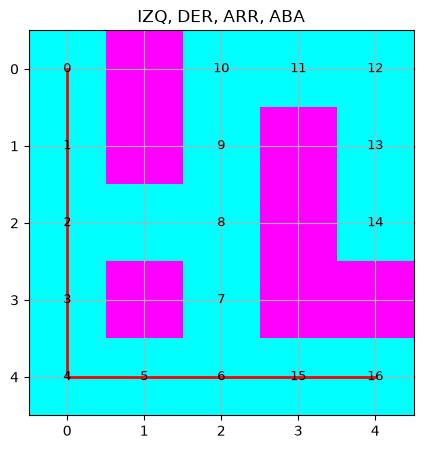

IZQ, ARR, ABA, DER: pasos=8, explorados=12, tiempo=0.022 ms
[(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4)]


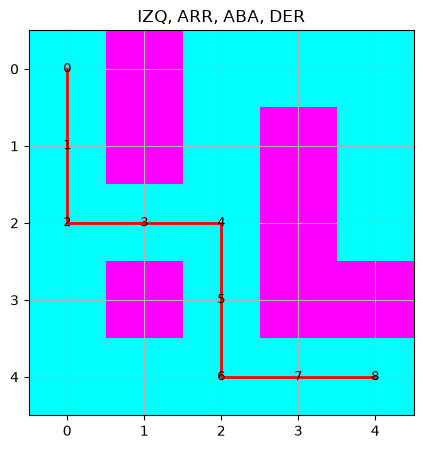

ABA, IZQ, ARR, DER: pasos=8, explorados=17, tiempo=0.039 ms
[(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4)]


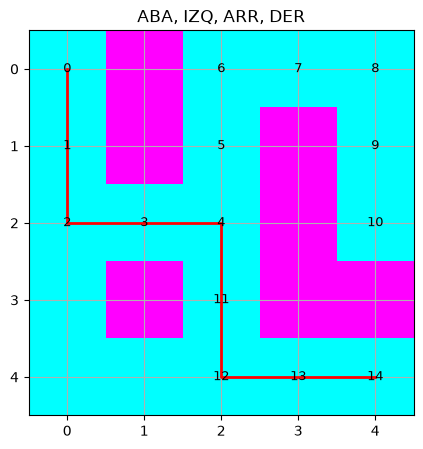

DER, ABA, IZQ, ARR: pasos=8, explorados=18, tiempo=0.036 ms
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]


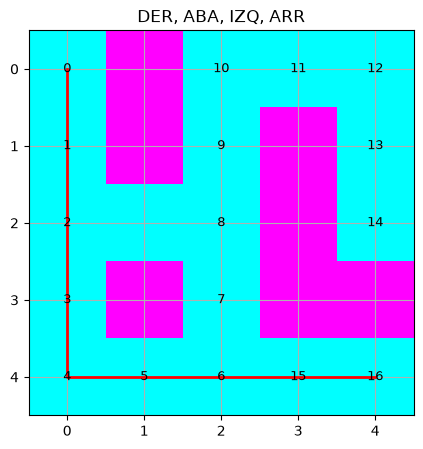

In [5]:
EXPERIMENTOS = [
    ("IZQ, DER, ARR, ABA", MOV_IZQ_DER_ARR_ABA, "1-izq-der-arr-aba.png"),
    ("IZQ, ARR, ABA, DER", MOV_IZQ_ARR_ABA_DER, "1-izq-arr-aba-der.png"),
    ("ABA, IZQ, ARR, DER", MOV_ABA_IZQ_ARR_DER, "1-aba-izq-arr-der.png"),
    ("DER, ABA, IZQ, ARR", MOV_DER_ABA_IZQ_ARR, "1-der-aba-izq-arr.png"),
]

CARPETA_IMAGENES = Path("../../results/uninformed-search/images")


def mostrar_laberinto(laberinto, camino, titulo, visitados, archivo):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(laberinto, cmap="cool")

    if camino:
        xs = [c for f, c in camino]
        ys = [f for f, c in camino]
        ax.plot(xs, ys, c="red", linewidth=2)

    # El número es el paso en que DFS sacó esa celda de la pila.
    for paso, (f, c) in enumerate(visitados):
        ax.text(
            c,
            f,
            str(paso),
            ha="center",
            va="center",
            fontsize=9,
            color="black",
            zorder=3,
        )

    ax.set_xticks(range(len(laberinto[0])))
    ax.set_yticks(range(len(laberinto)))
    ax.set_title(titulo)
    ax.grid(True)
    fig.savefig(archivo, bbox_inches="tight")
    plt.show()


for nombre, movimientos, archivo in EXPERIMENTOS:
    resultado = dfs_camino_laberinto(laberinto, INICIO, OBJETIVO, movimientos)
    print(
        f"{nombre}: pasos={len(resultado['camino']) - 1}, "
        f"explorados={resultado['explorados']}, "
        f"tiempo={resultado['tiempo'] * 1000:.3f} ms"
    )
    print(resultado["camino"])
    mostrar_laberinto(
        laberinto,
        resultado["camino"],
        nombre,
        resultado["visitados"],
        CARPETA_IMAGENES / archivo,
    )
